# 02 · The Magnitude Model

**Purpose.** Notebook 01 predicts *which* state a trip lands in. Three of the four states carry a determined revenue outcome once the state is known:

| State | Revenue |
|---|---|
| `no_purchase` | zero |
| `unchanged` | full coverage: every travelling line, every travelled day |
| `reduces` | **unknown — needs a size** |
| `increases` | **unknown — needs a size** |

A trip that reduces from ten days to nine and one that reduces from ten to two are the same state and nowhere near the same money. This notebook supplies the size, so notebook 03 can compute

$$\mathbb{E}[\text{revenue}] = \sum_{\text{state}} P(\text{state}) \times \text{revenue}(\text{state})$$

with a real number in every term.

**Two models, fitted only on trips in the relevant state**

| Model | Target | Form |
|---|---|---|
| Reduction depth | days bought / days travelled, and lines active / lines travelling | Binomial proportion, weighted by trip length |
| Increase size | extra days bought beyond days travelled | Positive count |

**Same architecture as notebook 01, for the same reason.**

1. Non-price features go to gradient-boosted trees fitted on standard-price trips only; price enters as a sign-constrained parametric term on top
2. Magnitude must respond to price — a bigger increase should produce a deeper cut, not merely more cutters — and that response has to be smooth and correctly signed everywhere

**One contamination to keep in view throughout.** The labels are reconstructed, not observed. The data notebook measured the `reduces` rule at roughly 0.72 precision, so about a quarter of the trips this model trains on are incidental one-day shortfalls rather than deliberate reductions. They are shallow by construction and pull the fitted depth toward zero. §5 sizes that bias rather than assuming it away.

In [1]:
# Load Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import minimize

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from IPython.display import display

DATA = Path("data/synthetic")


def load(name):
    pq, csv = DATA / f"{name}.parquet", DATA / f"{name}.csv"
    if pq.exists():
        return pd.read_parquet(pq)
    if csv.exists():
        return pd.read_csv(csv)
    raise FileNotFoundError(f"{name} not found in {DATA.resolve()} — run data/00_generate_and_validate_data.ipynb and notebook 01 first.")


accounts = load("accounts")
macro = load("macro")
trips = load("trips").merge(accounts, on="account_id", how="left")
trips = trips.merge(macro[["month", "macro_index"]], on="month", how="left")

PRICE_FIRST, PRICE_ADDL = 10.0, 5.0
DAY_THRESH = 0.70                      # the rule the data notebook selected
# Shared price grid, used in §3/§7/§8 — defined once so no cell can silently diverge
GRID = np.round(np.linspace(0.90, 1.20, 13), 4)

SURFACE = "#ffffff"
INK = "#0b0b0b"
MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"
ACCENT = "#2a78d6"
ACCENT2 = "#eb6834"
RED = "#e34948"

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": BASELINE,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "grid.color": GRIDLINE,
    "grid.linewidth": 0.8,
    "font.size": 9,
    "text.color": INK,
    "axes.labelcolor": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
})

print(f"{len(trips):,} trips loaded")

94,579 trips loaded


---
## 1 · Labels, Features and the Split

**Purpose:** Rebuilds notebook 01's labels, features, and split exactly, so the state and magnitude models describe the same population.

**Design Notes:**

1. Identical to notebook 01 by design: label rule, leakage exclusions, expanding-window history, and temporal split all carry over unchanged
  - If they differed, the state probabilities and the magnitudes would describe different populations

**Observations:**

1. Reconstructed labels: unchanged 68,763, reduces 10,724, no_purchase 8,972, increases 6,120
2. reduces: 8,709 train / 2,015 test; increases: 4,887 train / 1,233 test — enough in both slices to fit and validate


In [2]:
# Rebuild Labels & Features
def reconstruct_label(df, day_thresh=DAY_THRESH):
    ratio = df["days_bought"] / df["days_traveled"]
    lines = df["lines_active"] / df["lines_traveling"].clip(lower=1)
    y = pd.Series("unchanged", index=df.index, dtype=object)
    y[ratio > 1.0] = "increases"
    y[(ratio < day_thresh) | (lines < 0.999)] = "reduces"
    y[df["days_bought"] == 0] = "no_purchase"
    return y


def build_features(df):
    out = pd.DataFrame(index=df.index)
    out["is_business"] = df["is_business"].astype(int)
    out["lines_on_account"] = df["lines_on_account"]
    out["tenure_months"] = df["tenure_months"]
    out["premium"] = (df["plan_tier"] == "premium").astype(int)
    out["value_tier"] = (df["plan_tier"] == "value").astype(int)
    out["lines_traveling"] = df["lines_traveling"]
    out["days_traveled"] = df["days_traveled"]
    for r in ["asia", "caribbean", "central_america", "europe", "mideast", "oceania", "south_america"]:  # africa omitted as reference
        out[f"region_{r}"] = (df["region"] == r).astype(int)
    out["month_of_year"] = df["month"] % 12
    out["macro_index"] = df["macro_index"]
    return out


trips["y"] = reconstruct_label(trips)
trips["log_price"] = np.log(trips["price_multiplier"])

hist = trips[["account_id", "month"]].sort_values(["account_id", "month"])
cum = hist.groupby("account_id").cumcount()
same = hist.groupby(["account_id", "month"]).cumcount()
trips["prior_trips"] = (cum - same).reindex(trips.index).fillna(0).astype(int)

X = build_features(trips)
X["prior_trips"] = trips["prior_trips"]

month = trips["month"].to_numpy()
tr, te = month <= 19, month >= 20            # no calibration slice needed here
STD = (trips["price_multiplier"] == 1.0).to_numpy()

display(trips["y"].value_counts().to_frame("count").rename_axis(None))
display(pd.DataFrame({
    "train": [((trips.y == "reduces") & tr).sum(), ((trips.y == "increases") & tr).sum()],
    "test": [((trips.y == "reduces") & te).sum(), ((trips.y == "increases") & te).sum()],
}, index=["reduces", "increases"]))

,count
unchanged,68763
reduces,10724
no_purchase,8972
increases,6120


,train,test
reduces,8709,2015
increases,4887,1233


---
## 2 · What Reduction Actually Looks Like

**Purpose:** Looks at the shape of what's being modelled before fitting anything, since the shape decides the model form.

**Design Notes:**

1. Is depth continuous or clustered?
  - If reductions pile up at one or two specific coverage levels, a conditional mean is the wrong summary
2. Does depth move with price, or only frequency?
  - The substantive question: if a price rise makes more people cut but doesn't make the cuts deeper, the revenue arithmetic is far simpler and the magnitude model matters much less
3. Chart: frequency and depth sit on different scales, shown as two stacked panels rather than one dual-axis chart, which would imply a false alignment

**Observations:**

1. Reduction depth: median coverage 0.50, ranging 0.06 to 1.00 — continuous, not clustered at one or two levels
2. Increase size: median 1 extra day, up to 6 at the 90th percentile — a right-skewed count
3. Both frequency and depth move with price: reduce rate rises from 7.9% to 16.5%, and mean coverage when reducing falls from 0.572 to 0.391, across the tested range
4. 7.2% of reducing trips also cut lines, not just days


Reduction depth


,value
count,10724.000
mean,0.498
std,0.156
min,0.056
10%,0.263
25%,0.333
50%,0.500
75%,0.667
90%,0.667
max,1.000


Lines also cut: 7.2% of reducing trips
Increase size (extra days)


,value
count,6120.00
mean,1.21
std,0.57
min,1.00
25%,1.00
50%,1.00
75%,1.00
90%,2.00
max,6.00


Depth by price — does a higher price cut deeper, or just cut more often?


,trips,reduce_rate,mean_coverage_when_reducing,mean_days_short
0.90,6722,0.0785,0.572,2.23
0.95,8045,0.0988,0.544,2.26
1.00,63248,0.1094,0.514,2.54
1.10,10065,0.1398,0.448,3.09
1.20,6499,0.1649,0.391,3.44


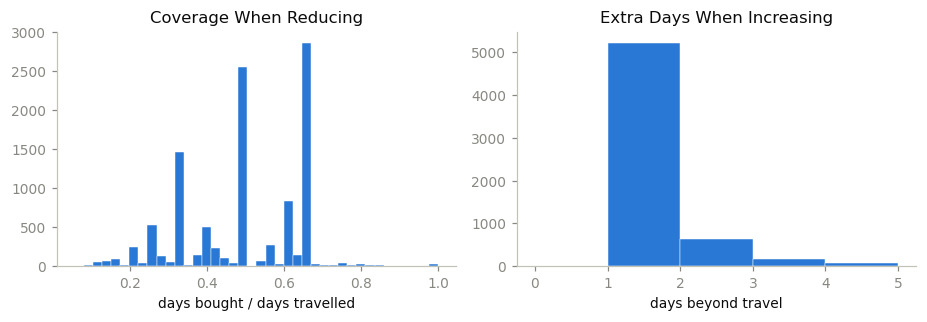

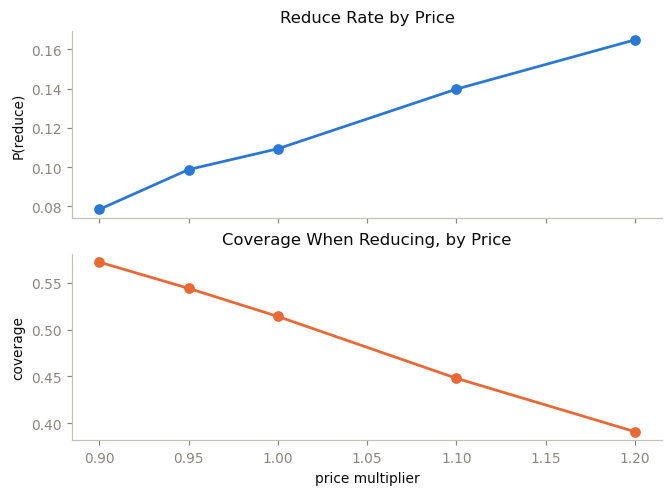

Both should move with price. If only the rate moves, the magnitude model
is a formality; if coverage falls too, the two effects compound.


In [3]:
# Examine Reduction Shape
red = trips[trips.y == "reduces"].copy()
red["day_cov"] = red["days_bought"] / red["days_traveled"]
red["line_cov"] = red["lines_active"] / red["lines_traveling"].clip(lower=1)
red["days_short"] = red["days_traveled"] - red["days_bought"]

inc = trips[trips.y == "increases"].copy()
inc["extra_days"] = inc["days_bought"] - inc["days_traveled"]

print("Reduction depth")
display(red["day_cov"].describe(percentiles=[.1, .25, .5, .75, .9]).round(3).to_frame("value"))
print(f"Lines also cut: {(red.line_cov < 0.999).mean():.1%} of reducing trips")

print("Increase size (extra days)")
display(inc["extra_days"].describe(percentiles=[.25, .5, .75, .9]).round(2).to_frame("value"))

print("Depth by price — does a higher price cut deeper, or just cut more often?")
depth = trips.assign(is_red=(trips.y == "reduces")).groupby("price_multiplier").agg(
    trips=("trip_id", "size"), reduce_rate=("is_red", "mean")).round(4)
depth["mean_coverage_when_reducing"] = red.groupby("price_multiplier")["day_cov"].mean().round(3)
depth["mean_days_short"] = red.groupby("price_multiplier")["days_short"].mean().round(2)
display(depth.rename_axis(None))

fig, axes = plt.subplots(1, 2, figsize=(8.5, 3))
axes[0].hist(red["day_cov"], bins=40, color=ACCENT, edgecolor=SURFACE, linewidth=0.3)
axes[0].set_title("Coverage When Reducing")
axes[0].set_xlabel("days bought / days travelled")

axes[1].hist(inc["extra_days"], bins=range(0, int(inc.extra_days.quantile(0.99)) + 2),
             color=ACCENT, edgecolor=SURFACE, linewidth=0.3)
axes[1].set_title("Extra Days When Increasing")
axes[1].set_xlabel("days beyond travel")
plt.tight_layout()
plt.show()

# Two stacked panels, not dual-axis (see Design Notes)
fig, axes = plt.subplots(2, 1, figsize=(6, 4.4), sharex=True, layout="constrained")
axes[0].plot(depth.index, depth["reduce_rate"], marker="o", color=ACCENT, linewidth=1.8)
axes[0].set_ylabel("P(reduce)")
axes[0].set_title("Reduce Rate by Price")

axes[1].plot(depth.index, depth["mean_coverage_when_reducing"], marker="o", color=ACCENT2, linewidth=1.8)
axes[1].set_xlabel("price multiplier")
axes[1].set_ylabel("coverage")
axes[1].set_title("Coverage When Reducing, by Price")
plt.show()

print("Both should move with price. If only the rate moves, the magnitude model")
print("is a formality; if coverage falls too, the two effects compound.")


---
## 3 · Reduction Depth

**Purpose:** Models how deep a reduction goes — days bought as a share of days travelled — not just whether one happens.

**Design Notes:**

1. Modelled as a binomial proportion: of the days available, how many get bought
  - Weighted by trip length, since a ten-day trip carries ten times the revenue information of a one-day trip
  - Tree stage fits the logit-transformed, exposure-weighted target under squared-error loss (an approximation, not a true binomial deviance fit); the parametric price term on top is a genuine weighted Bernoulli log-likelihood
2. Two components, since a household can cut days, cut lines, or both
  - Day coverage: days_bought / days_traveled
  - Line coverage: lines_active / lines_traveling
3. Same architecture as notebook 01: trees on non-price features fitted on standard-price trips only, then a parametric price term
  - Fitting the trees on all prices would let them learn the price effect through region and month, the same contamination notebook 01 fixed

**Observations:**

1. Day-coverage price coefficient -2.98 (business interaction +0.52); line-coverage coefficient hits its bound at -1.5, flagged as not identified — only 7.2% of reducing trips cut lines at all
2. Zero wrong-signed net effects on either channel
3. Held-out MAE (0.121) beats the constant baseline (0.122)
4. Predicted coverage falls smoothly and monotonically from 0.58 to 0.40 across the tested range, with zero monotonicity violations


In [4]:
# Fit Reduction Depth
def logit(p):
    p = np.clip(p, 1e-4, 1 - 1e-4)
    return np.log(p / (1 - p))


def expit(z):
    return 1.0 / (1.0 + np.exp(-z))


BOUND = -5.0      # a coefficient at the wall means unidentified, not strong


def fit_coverage(target_col, denom_col, label, bound=None):
    """Trees on non-price features (standard price only), then a price term."""
    m_red = (trips.y == "reduces").to_numpy()
    fit_rows = m_red & tr & STD
    n = trips[denom_col].to_numpy().clip(1)
    cov = (trips[target_col].to_numpy() / n)

    base = HistGradientBoostingRegressor(
        max_iter=300, learning_rate=0.06, max_leaf_nodes=15, min_samples_leaf=40,
        l2_regularization=1.0, early_stopping=True, validation_fraction=0.15,
        random_state=0,
    ).fit(X[fit_rows], logit(cov[fit_rows]), sample_weight=n[fit_rows])

    # Parametric price term: higher price -> lower coverage, enforced by a bound.
    rows = m_red & tr
    z0 = base.predict(X[rows])
    lp = trips.loc[rows, "log_price"].to_numpy()
    biz = trips.loc[rows, "is_business"].to_numpy().astype(float)
    obs = cov[rows]
    wt = n[rows]

    def loss(th):
        z = z0 + th[0] * lp + th[1] * lp * biz
        p = expit(z)
        return -np.sum(wt * (obs * np.log(np.clip(p, 1e-9, 1)) +
                             (1 - obs) * np.log(np.clip(1 - p, 1e-9, 1)))) / wt.sum()

    lo = BOUND if bound is None else bound
    r = minimize(loss, np.zeros(2), method="L-BFGS-B",
                 bounds=[(lo, 0), (-4, 4)], options={"maxiter": 400})
    theta = r.x
    if abs(theta[0] - lo) < 1e-6:
        print(f"  WARNING: price coefficient pinned at the bound ({lo}). The")
        print("  parameter is not identified — too few trips move this channel.")

    net = theta[0] + theta[1] * biz
    refit = (net > 0).mean() > 0.01
    if refit:
        print(f"{label}: initial fit had {((net > 0).mean()):.2%} wrong-signed net effect —")
        print("  refitting without the interaction to guarantee the sign")
        r = minimize(loss, np.zeros(2), method="L-BFGS-B",
                     bounds=[(lo, 0), (0, 0)], options={"maxiter": 400})
        theta = r.x
        net = theta[0] + theta[1] * biz

    # Print after any refit, so diagnostics always match the theta returned
    print(f"{label}: price coefficient {theta[0]:+.3f}, business interaction {theta[1]:+.3f}"
          f"{'  (refit, no interaction)' if refit else ''}")
    print(f"  net effect min/median/max {net.min():+.3f} / {np.median(net):+.3f} / {net.max():+.3f}"
          f"   wrong sign: {(net > 0).mean():.2%}")
    return base, theta


print("Fitting reduction depth")
day_base, day_theta = fit_coverage("days_bought", "days_traveled", "day coverage ")
# Tight bound: only a minority of trips cut lines, so this channel is thin
line_share = ((trips.y == "reduces") &
              (trips.lines_active < trips.lines_traveling)).sum() / max((trips.y == "reduces").sum(), 1)
print(f"line cuts occur on {line_share:.1%} of reducing trips")
line_base, line_theta = fit_coverage("lines_active", "lines_traveling", "line coverage",
                                     bound=-1.5)


def predict_coverage(base, theta, Xf, df, mult=None):
    lp = np.log(float(mult)) * np.ones(len(df)) if mult is not None \
        else df["log_price"].to_numpy()
    z = base.predict(Xf) + theta[0] * lp + theta[1] * lp * df["is_business"].to_numpy().astype(float)
    return np.clip(expit(z), 0.02, 1.0)

Fitting reduction depth


day coverage : price coefficient -2.980, business interaction +0.516
  net effect min/median/max -2.980 / -2.464 / -2.464   wrong sign: 0.00%
line cuts occur on 7.2% of reducing trips


  parameter is not identified — too few trips move this channel.
line coverage: price coefficient -1.500, business interaction -4.000
  net effect min/median/max -5.500 / -5.500 / -1.500   wrong sign: 0.00%


Day coverage, held-out trips that reduced


,MAE,R2,mean predicted
model,0.1213,0.0313,0.5133
constant (train mean),0.1222,-0.0104,0.4952


observed mean coverage on test: 0.5104

The model has to beat the constant on MAE. Coverage is a narrow, noisy
quantity, so a modest R2 is expected — the aggregate mean matters more,
since that is what the revenue arithmetic consumes.

Predicted coverage at 0.90 / 1.00 / 1.20: 0.5847 / 0.5156 / 0.3966
Monotonicity violations across the range: 0


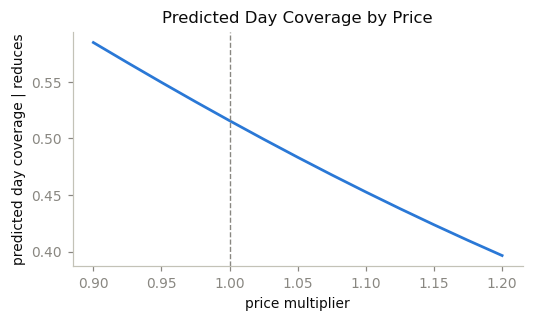

In [5]:
# Validate Depth Model
m_te = ((trips.y == "reduces") & te).to_numpy()
df_te = trips[m_te]
obs_cov = (df_te["days_bought"] / df_te["days_traveled"]).to_numpy()
pred_cov = predict_coverage(day_base, day_theta, X[m_te], df_te)

train_mean = ((trips.loc[(trips.y == "reduces") & tr, "days_bought"] /
               trips.loc[(trips.y == "reduces") & tr, "days_traveled"]).mean())
const_pred = np.full_like(obs_cov, train_mean)

print("Day coverage, held-out trips that reduced")
# A train-mean constant's test-set R2 is only exactly 0 by coincidence
display(pd.DataFrame({
    "MAE": [mean_absolute_error(obs_cov, pred_cov),
            mean_absolute_error(obs_cov, const_pred)],
    "R2": [r2_score(obs_cov, pred_cov), r2_score(obs_cov, const_pred)],
    "mean predicted": [pred_cov.mean(), train_mean],
}, index=["model", "constant (train mean)"]).round(4))
print(f"observed mean coverage on test: {obs_cov.mean():.4f}")
print("\nThe model has to beat the constant on MAE. Coverage is a narrow, noisy")
print("quantity, so a modest R2 is expected — the aggregate mean matters more,")
print("since that is what the revenue arithmetic consumes.")

# GRID defined once in imports, reused in §7/§8
curve = [predict_coverage(day_base, day_theta, X[m_te], df_te, m).mean() for m in GRID]
viol = int((np.diff(curve) > 1e-9).sum())
print(f"\nPredicted coverage at 0.90 / 1.00 / 1.20: "
      f"{curve[0]:.4f} / {curve[len(curve)//3]:.4f} / {curve[-1]:.4f}")
print(f"Monotonicity violations across the range: {viol}")

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(GRID, curve, color=ACCENT, linewidth=1.8)
ax.axvline(1.0, color=MUTED, linestyle="--", linewidth=0.9)
ax.set_xlabel("price multiplier")
ax.set_ylabel("predicted day coverage | reduces")
ax.set_title("Predicted Day Coverage by Price")
plt.tight_layout()
plt.show()

---
## 4 · Increase Size

**Purpose:** Models how many extra days an increasing trip buys beyond what it travelled.

**Design Notes:**

1. Modelled on the log scale and exponentiated back: a positive count with a floor of one
2. Price term carries the opposite sign from reductions: a deeper discount buys more extra days
3. Increases aren't confined to discounted trips
  - Some accounts buy beyond their travel days at any price, for convenience or unplanned extensions
  - Most volume sits at the standard rate, so the price term is estimated off a thin slice at the edges of the range and should be read as weak
  - A coefficient of zero would be a real finding about this population, not a broken fit

**Observations:**

1. 30.0% of increases occur away from the standard rate — the slice the price term is estimated from
2. Price coefficient -2.429 on log extra days: a deeper discount buys more days, as expected
3. Held-out MAE (0.112) beats the constant baseline (0.287) by a wide margin
4. Mean predicted extra days (1.04) close to observed (1.09)


In [6]:
# Fit Increase Size
m_inc = (trips.y == "increases").to_numpy()
extra = (trips["days_bought"] - trips["days_traveled"]).to_numpy().astype(float)

print("Price levels at which increases occur")
display(trips.loc[m_inc, "price_multiplier"].value_counts().sort_index().to_frame("count").rename_axis(None))
off_std = trips.loc[m_inc, "price_multiplier"].ne(1.0).mean()
print(f"{off_std:.1%} of increases occur away from the standard rate — the price term")
print("is estimated off that slice, so treat it as weakly identified.")

fit_rows = m_inc & tr & STD
if fit_rows.sum() < 50:
    # No increases at the standard rate: fall back to all training increases and say so.
    fit_rows = m_inc & tr
    print("\nToo few increases at the standard rate; the tree is fitted on all")
    print("training increases. Price and baseline are less cleanly separated here.")

inc_base = HistGradientBoostingRegressor(
    max_iter=200, learning_rate=0.06, max_leaf_nodes=15, min_samples_leaf=30,
    l2_regularization=1.0, early_stopping=True, validation_fraction=0.15, random_state=0,
).fit(X[fit_rows], np.log(np.clip(extra[fit_rows], 1, None)))

rows = m_inc & tr
z0 = inc_base.predict(X[rows])
lp = trips.loc[rows, "log_price"].to_numpy()
obs = np.log(np.clip(extra[rows], 1, None))


def inc_loss(th):
    return np.mean((obs - (z0 + th[0] * lp)) ** 2)


inc_theta = minimize(inc_loss, np.zeros(1), method="L-BFGS-B",
                     bounds=[(-15, 0)], options={"maxiter": 300}).x
print(f"price coefficient on log extra days: {inc_theta[0]:+.3f} "
      f"(negative = a deeper discount buys more days)")
if abs(inc_theta[0]) < 1e-6:
    print("Zero: increase size does not respond to price in this population.")
    print("Revenue from increases then scales with price only, not with volume.")


def predict_extra(base, theta, Xf, df, mult=None):
    """Same convention as predict_coverage: self-contained, no closures."""
    lp = np.log(float(mult)) * np.ones(len(df)) if mult is not None \
        else df["log_price"].to_numpy()
    return np.clip(np.exp(base.predict(Xf) + theta[0] * lp), 1.0, 30.0)


m_ite = m_inc & te
if m_ite.sum() > 20:
    pe = predict_extra(inc_base, inc_theta, X[m_ite], trips[m_ite])
    oe = extra[m_ite]
    print(f"Held-out increases: n={m_ite.sum():,}")
    print(f"  MAE model {mean_absolute_error(oe, pe):.3f}  vs constant "
          f"{mean_absolute_error(oe, np.full_like(oe, extra[rows].mean())):.3f}")
    print(f"  mean predicted {pe.mean():.2f}  observed {oe.mean():.2f}")
else:
    print(f"\nOnly {m_ite.sum()} increases in the test window — not enough to validate.")

Price levels at which increases occur


,count
0.90,517
0.95,611
1.00,4286
1.10,475
1.20,231


30.0% of increases occur away from the standard rate — the price term
is estimated off that slice, so treat it as weakly identified.


price coefficient on log extra days: -2.429 (negative = a deeper discount buys more days)
Held-out increases: n=1,233
  MAE model 0.112  vs constant 0.287
  mean predicted 1.04  observed 1.09


---
## 5 · Label Contamination: How Much Does It Bias the Depth?

**Purpose:** Measures how much the reconstructed-label rule's false positives bias the fitted depth, since this model trains on labelled reduces, not true reduces.

**Design Notes:**

1. The data notebook measured the reduces rule at roughly 0.72 precision
  - False positives are incidental one-day shortfalls, shallow by construction
  - Biases the fitted depth toward zero, and expected revenue toward optimistic
2. Because this is synthetic data, the bias is directly measurable
  - Compares depth among truly-reducing trips against depth among all labelled ones
  - Exported as a correction factor so notebook 03 can run the simulation with and without it
3. In production this number is unknowable, which is the argument for having built it here

**Observations:**

1. Label rule precision here: 77.6% (2,398 of 10,724 labelled trips are false positives)
2. True cuts run deeper: mean coverage 0.470 among truly-reducing trips vs. 0.498 among all labelled, and 0.594 among the false positives
3. Depth bias: 1.06x — true cuts are 6% deeper than the labelled average


In [7]:
# Measure Label Contamination
truth = trips["state"].replace({"substitutes": "no_purchase", "leaves": "no_purchase"})
labelled = trips.y == "reduces"
truly = labelled & (truth == "reduces")
falsely = labelled & (truth != "reduces")

cov_all = (trips.loc[labelled, "days_bought"] / trips.loc[labelled, "days_traveled"]).mean()
cov_true = (trips.loc[truly, "days_bought"] / trips.loc[truly, "days_traveled"]).mean()

display(pd.DataFrame({
    "trips": [labelled.sum(), truly.sum(), falsely.sum()],
    "mean coverage": [cov_all, cov_true,
                      (trips.loc[falsely, "days_bought"] /
                       trips.loc[falsely, "days_traveled"]).mean() if falsely.sum() else np.nan],
}, index=["labelled reduces", "truly reduces", "false positives"]).round(4))

print(f"Precision of the label rule here: {truly.sum() / max(labelled.sum(), 1):.3f}")
DEPTH_BIAS = float((1 - cov_true) / max(1 - cov_all, 1e-9))
print(f"True cuts are {DEPTH_BIAS:.2f}x deeper than the labelled average.")
print("Exported as depth_bias. Notebook 03 runs the simulation at 1.0 and at this")
print("factor; the gap between them is the cost of not observing the state directly.")

,trips,mean coverage
labelled reduces,10724,0.4981
truly reduces,8326,0.4705
false positives,2398,0.5940


Precision of the label rule here: 0.776
True cuts are 1.06x deeper than the labelled average.
Exported as depth_bias. Notebook 03 runs the simulation at 1.0 and at this
factor; the gap between them is the cost of not observing the state directly.


---
## 6 · Revenue per State

**Purpose:** Applies the pricing identity per state with the predicted magnitudes filled in, as the single interface notebook 03 calls.

**Design Notes:**

1. Pricing identity: revenue = (10 + 5 × (lines_active − 1)) × days_bought × price_multiplier
2. Filled in per state

| State | lines | days |
|---|---|---|
| no_purchase | 0 | 0 |
| unchanged | all travelling | all travelled |
| reduces | predicted line coverage | predicted day coverage |
| increases | all travelling | travelled + predicted extra |

3. `revenue_by_state` is the one function notebook 03 calls — one interface, not a set of loose predictions, keeps the two notebooks from drifting apart

**Observations:**

1. Mean revenue per trip at standard price: no_purchase 0.00, reduces 34.21, unchanged 67.06, increases 79.40
2. Predicted vs. actual revenue is close for unchanged (67.06 vs. 66.04) and reasonably close for reduces (34.21 vs. 30.28)
3. increases slightly under-predicts actual (79.40 vs. 81.19), within the range this check is meant to catch
4. End-to-end check on 18,472 held-out trips: expected total $1,071,901 vs. observed $1,051,766, a +1.91% error — within the few-percent target


In [8]:
# Compute Revenue by State
CLASSES = ["no_purchase", "reduces", "unchanged", "increases"]


def revenue_by_state(Xf, df, mult=1.0, depth_scale=1.0):
    """Revenue each trip would produce in each state, at price `mult`.

    depth_scale > 1 deepens predicted reductions, for the §5 contamination
    bracket. Returns an (n, 4) array in CLASSES order.
    """
    lines_t = df["lines_traveling"].to_numpy().astype(float)
    days_t = df["days_traveled"].to_numpy().astype(float)

    def rev(lines, days):
        lines = np.maximum(lines, 0)
        return np.where(lines > 0,
                        (PRICE_FIRST + PRICE_ADDL * (lines - 1)) * days * mult, 0.0)

    day_cov = predict_coverage(day_base, day_theta, Xf, df, mult)
    line_cov = predict_coverage(line_base, line_theta, Xf, df, mult)
    day_cov = np.clip(1 - depth_scale * (1 - day_cov), 0.02, 1.0)
    line_cov = np.clip(1 - depth_scale * (1 - line_cov), 0.02, 1.0)

    out = np.zeros((len(df), 4))
    out[:, CLASSES.index("no_purchase")] = 0.0
    out[:, CLASSES.index("unchanged")] = rev(lines_t, days_t)
    out[:, CLASSES.index("reduces")] = rev(np.maximum(np.round(lines_t * line_cov), 1),
                                           np.maximum(np.round(days_t * day_cov), 1))
    out[:, CLASSES.index("increases")] = rev(lines_t, days_t + predict_extra(inc_base, inc_theta, Xf, df, mult))
    return out


R = revenue_by_state(X[te], trips[te], 1.0)
print("Mean revenue per trip by state, at the standard price")

print("Against what actually happened on those trips")
act = trips[te].groupby("y")["pass_revenue"].mean().reindex(CLASSES)
display(pd.DataFrame({"predicted": pd.Series(R.mean(0), index=CLASSES),
                      "actual": act}).round(2))
print("These should be close for unchanged and reduces. A large gap on reduces")
print("means the depth model is off in a way that flows straight into the revenue.")

Mean revenue per trip by state, at the standard price
Against what actually happened on those trips


,predicted,actual
no_purchase,0.00,0.00
reduces,34.21,30.28
unchanged,67.06,66.04
increases,79.40,81.19


These should be close for unchanged and reduces. A large gap on reduces
means the depth model is off in a way that flows straight into the revenue.


In [9]:
# End-to-End Check
scored = load("scored_trips")
sc_te = scored[scored["slice"] == "test"].set_index("trip_id")
te_ids = trips.loc[te, "trip_id"]
common = te_ids[te_ids.isin(sc_te.index)]

if len(common) > 0:
    idx = trips["trip_id"].isin(common).to_numpy() & te
    P = sc_te.loc[trips.loc[idx, "trip_id"], [f"p_{c}" for c in CLASSES]].to_numpy()
    Rv = revenue_by_state(X[idx], trips[idx], 1.0)
    exp_rev = (P * Rv).sum(axis=1)
    obs_rev = trips.loc[idx, "pass_revenue"].to_numpy()

    print(f"Expected vs observed revenue on {idx.sum():,} held-out trips")
    display(pd.DataFrame({
        "expected": [exp_rev.sum(), exp_rev.mean()],
        "observed": [obs_rev.sum(), obs_rev.mean()],
    }, index=["total", "per trip"]).round(2))
    print(f"error: {(exp_rev.sum() / obs_rev.sum() - 1):+.2%}")
    print("This is the number that matters — the simulation repeats this calculation")
    print("across prices, so an error here scales into every scenario.")
    REV_ERROR = float(exp_rev.sum() / obs_rev.sum() - 1)
else:
    REV_ERROR = np.nan
    print("scored_trips does not overlap the test window — re-run notebook 01.")

Expected vs observed revenue on 18,472 held-out trips


,expected,observed
total,1071901.09,1051766.00
per trip,58.03,56.94


error: +1.91%
This is the number that matters — the simulation repeats this calculation
across prices, so an error here scales into every scenario.


---
## 7 · The Revenue Curve

**Purpose:** Previews notebook 03's answer by combining state probabilities and magnitudes across the price range, without macro uncertainty, seasonality, or departure cost.

**Design Notes:**

1. A deterministic sketch of the shape, not the final answer
  - Uses depth_scale=1.0, the raw fitted depth before §5's contamination correction; notebook 03 compares the bracketed versions
2. Two things it should show
  - A smooth curve with no kinks
  - Whether revenue is still climbing at +20% — if so, the recommendation is bounded by the cap, not an interior optimum, and must be reported as a constraint

**Observations:**

1. Revenue-maximising price in the tested range: 1.20 (the cap)
2. Revenue is still climbing at the +20% ceiling — the constraint chose this price, not the model


,revenue,vs_standard
0.900,1010474.0,-0.0618
0.925,1027821.0,-0.0456
0.950,1044773.0,-0.0299
0.975,1061305.0,-0.0146
1.000,1076985.0,0.0000
1.025,1092947.0,0.0148
1.050,1109055.0,0.0298
1.075,1123904.0,0.0436
1.100,1136846.0,0.0556
1.125,1149132.0,0.0670


Revenue-maximising price in the tested range: 1.200
Revenue is still climbing at the +20% ceiling. The cap is binding, so the
recommendation is a bounded answer: the constraint chose +20%, not the model.


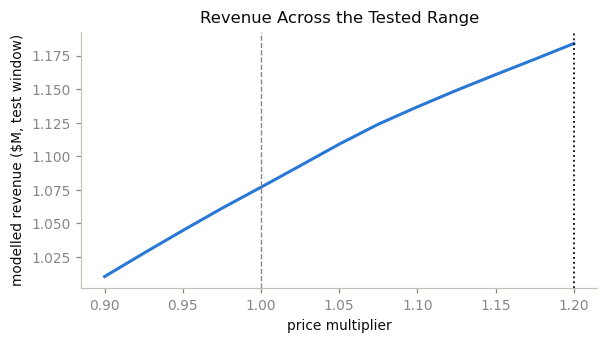

In [10]:
# Build Revenue Curve
sweep = load("price_sweep").set_index("price_multiplier")
base_rev = trips.loc[te, "pass_revenue"].sum()

rows = []
for m in GRID:
    if float(m) in sweep.index:
        p = sweep.loc[float(m), CLASSES].to_numpy()
    else:
        j = np.argmin(np.abs(sweep.index.to_numpy() - m))
        p = sweep.iloc[j][CLASSES].to_numpy()
    Rv = revenue_by_state(X[te], trips[te], m)
    rows.append({"price_multiplier": m, "revenue": float((Rv * p).sum(axis=1).sum())})

curve = pd.DataFrame(rows).set_index("price_multiplier")
curve["vs_standard"] = curve["revenue"] / curve.loc[1.0, "revenue"] - 1
display(curve.round({"revenue": 0, "vs_standard": 4}).rename_axis(None))

best = curve["revenue"].idxmax()
print(f"Revenue-maximising price in the tested range: {best:.3f}")
if best >= GRID[-1] - 1e-9:
    print("Revenue is still climbing at the +20% ceiling. The cap is binding, so the")
    print("recommendation is a bounded answer: the constraint chose +20%, not the model.")

fig, ax = plt.subplots(figsize=(5.6, 3.2))
ax.plot(curve.index, curve["revenue"] / 1e6, color=ACCENT, linewidth=2)
ax.axvline(1.0, color=MUTED, linestyle="--", linewidth=0.9)
ax.axvline(1.20, color=INK, linestyle=":", linewidth=1.2)
ax.set_xlabel("price multiplier")
ax.set_ylabel("modelled revenue ($M, test window)")
ax.set_title("Revenue Across the Tested Range")
plt.tight_layout()
plt.show()

---
## 8 · Export

**Purpose:** Writes the per-trip predicted magnitudes, the revenue-by-state lookup table, the deterministic revenue curve, and model metadata that notebook 03 loads.

**Design Notes:**

1. `revenue_by_state` is evaluated across the full price grid here and exported as a table, not called live — notebook 03 loads and pivots it
2. `depth_bias` (§5) and `revenue_error` (§6) travel with the export, so notebook 03 can bracket the simulation rather than assume the contamination away

**Observations:**

1. Four tables written: trip magnitudes, revenue by state, the deterministic revenue curve, and model metadata
2. depth_bias 1.06x, revenue reproduction error +1.9%


In [11]:
# Export Results
mag = trips[["trip_id", "account_id", "month", "price_multiplier"]].copy()
mag["pred_day_coverage"] = predict_coverage(day_base, day_theta, X, trips)
mag["pred_line_coverage"] = predict_coverage(line_base, line_theta, X, trips)
mag["pred_extra_days"] = predict_extra(inc_base, inc_theta, X, trips)

# Revenue per state at each price on the grid — the simulation's lookup table
tbl = []
for m in GRID:
    Rv = revenue_by_state(X, trips, m)
    tbl.append(pd.DataFrame({"trip_id": trips["trip_id"].to_numpy(),
                             "price_multiplier": m,
                             **{f"rev_{c}": Rv[:, i] for i, c in enumerate(CLASSES)}}))
rev_tbl = pd.concat(tbl, ignore_index=True)

meta = pd.DataFrame({
    "key": ["depth_bias", "revenue_error", "day_price_coef", "line_price_coef",
            "extra_price_coef"],
    "value": [DEPTH_BIAS, REV_ERROR, float(day_theta[0]), float(line_theta[0]),
              float(inc_theta[0])],
})
display(meta.set_index("key").rename_axis(None))

FMT = "parquet"
try:
    import pyarrow  # noqa: F401
except ImportError:
    try:
        import fastparquet  # noqa: F401
    except ImportError:
        FMT = "csv"
        print("\npyarrow/fastparquet not found, writing CSV instead.")

paths, rows = [], []
for df, name in [(mag, "trip_magnitudes"), (rev_tbl, "revenue_by_state"),
                 (curve.reset_index(), "deterministic_revenue_curve"),
                 (meta, "magnitude_meta")]:
    path = DATA / f"{name}.{FMT}"
    df.to_parquet(path, index=False) if FMT == "parquet" else df.to_csv(path, index=False)
    paths.append(path.name)
    rows.append(len(df))

display(pd.DataFrame({"rows": rows}, index=paths).rename_axis(None))

,value
depth_bias,1.055014
revenue_error,0.019144
day_price_coef,-2.979781
line_price_coef,-1.500000
extra_price_coef,-2.428731


,rows
trip_magnitudes.parquet,94579
revenue_by_state.parquet,1229527
deterministic_revenue_curve.parquet,13
magnitude_meta.parquet,5


---
## What this notebook establishes

| Result | Where | Consequence |
|---|---|---|
| Depth moves with price, not just frequency | §2–3 | A state-only model would understate the damage |
| Coverage model beats the constant | §3 | The magnitude carries real information |
| Depth response smooth and correctly signed | §3 | Simulation curves stay defensible |
| Increase size identified on discounts only | §4 | Stated as a limit, not hidden |
| Label contamination sized | §5 | Exported as a bracket, not assumed away |
| Expected revenue reproduces observed | §6 | The composition is arithmetically sound |
| Revenue still climbing at +20% | §7 | The cap binds — a constraint, not an optimum |

### Carry into notebook 03

1. **`revenue_by_state(X, df, mult, depth_scale)`** is evaluated across the full `GRID` here and exported as `revenue_by_state.parquet` in §8 — notebook 03 loads that table (it does not call this function live), pivots it to `rev_{state}` columns per price, and combines it with notebook 01's `score_trips` output the same way §6's end-to-end check does: `Σ P(state) × revenue(state)`.
2. **Bracket twice, not once.** `response_scale` from notebook 01 §6.2 and `depth_scale` from §5 here are independent sources of optimism, and both push the same direction: the unbracketed answer overstates how safe a price rise is.
3. **`no_purchase` is not free.** The revenue table books it at zero, which is right for the pass but wrong for the relationship. Departures carry account-level value, and notebook 03 has to subtract it using the bootstrapped rate from notebook 01 §10.

### Next

`03_simulation.ipynb` — 12 months forward across the price range, with the macro shock drawn once per iteration and applied to every account, so the revenue distribution has an honest width.